In [ ]:
# importing required Libraries
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_clean_2021.csv")

In [2]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 - 1000,1973,...,0,0,1,1,0,0,0,data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+,1984,...,0,0,0,0,0,0,0,data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 - 1000,2010,...,0,0,0,0,0,0,0,data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 - 5000,1965,...,0,0,0,0,0,0,0,data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 - 200,1998,...,0,0,0,0,0,0,0,data scientist,na,na


There are many columns which we wont be needing for further process. So, to make the dataset little clean and focus only on what we need i will be keeping only those columns which i would use.

In [14]:
print(df.columns)

Index(['index', 'Job Title', 'Salary Estimate', 'Rating', 'Company Name',
       'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership',
       'Industry', 'Sector', 'Revenue', 'Competitors', 'Hourly',
       'Employer provided', 'Lower Salary', 'Upper Salary', 'Avg Salary(K)',
       'company_txt', 'Job Location', 'Age', 'Python', 'spark', 'aws', 'excel',
       'sql', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop',
       'tableau', 'bi', 'flink', 'mongo', 'google_an', 'job_title_sim',
       'seniority_by_title', 'Degree', 'company_name', 'rating'],
      dtype='object')


In [ ]:
# Trimming only the column we need
columns_needed = [
    "company_name",
    "rating",
    "Avg Salary(K)",
    "Industry",
    "Sector",
    "Age",
    "Python",
    "sql",
    "excel",
    "aws",
    "spark",
    "tableau"
]

df = df[columns_needed]

In [16]:
df.head()

,company_name,rating,Avg Salary(K),Industry,Sector,Age,Python,sql,excel,aws,spark,tableau
0,Tecolote Research,3.8,72.0,Aerospace & Defense,Aerospace & Defense,48,1,0,1,0,0,1
1,University of Maryland Medical System,3.4,87.5,Health Care Services & Hospitals,Health Care,37,1,0,0,0,0,0
2,KnowBe4,4.8,85.0,Security Services,Business Services,11,1,1,1,0,1,0
3,PNNL,3.8,76.5,Energy,"Oil, Gas, Energy & Utilities",56,1,0,0,0,0,0
4,Affinity Solutions,2.9,114.5,Advertising & Marketing,Business Services,23,1,1,1,0,0,0


# 1. Average Salary by Company Age

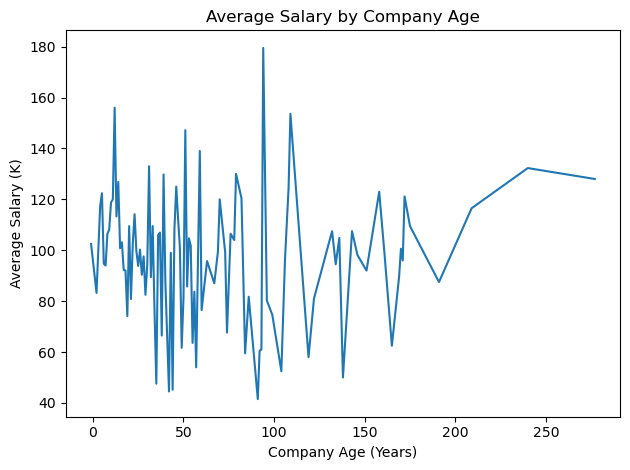

In [8]:
salary_by_age = df.groupby("Age")["Avg Salary(K)"].mean()

fig, ax = plt.subplots()

ax.plot(salary_by_age.index, salary_by_age.values)

ax.set_title("Average Salary by Company Age")
ax.set_xlabel("Company Age (Years)")
ax.set_ylabel("Average Salary (K)")

plt.tight_layout()
plt.show()

# 2. Top Industries Hiring Data Scientists

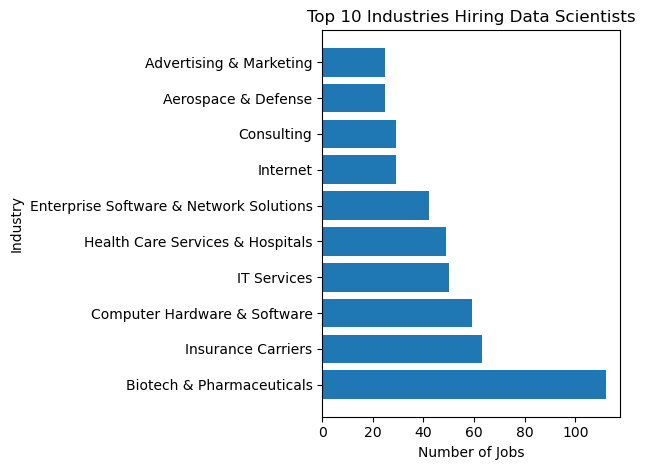

In [9]:
industry_counts = df["Industry"].value_counts().head(10)

fig, ax = plt.subplots()

ax.barh(industry_counts.index, industry_counts.values)

ax.set_title("Top 10 Industries Hiring Data Scientists")
ax.set_xlabel("Number of Jobs")
ax.set_ylabel("Industry")

plt.tight_layout()
plt.show()

# 3. Job Ratings vs Average Salary

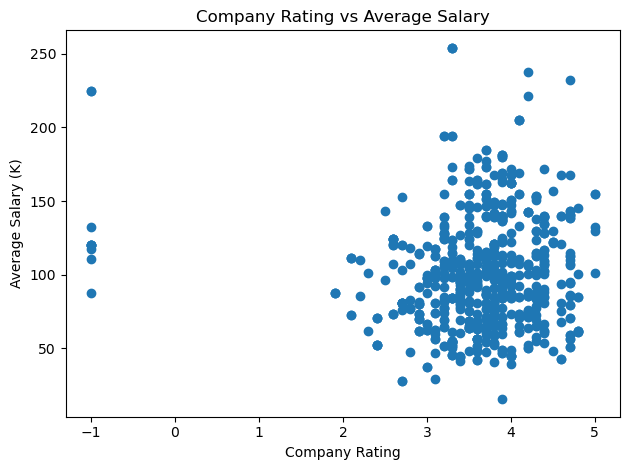

In [13]:
fig, ax = plt.subplots()

ax.scatter(df["Rating"], df["Avg Salary(K)"])

ax.set_title("Company Rating vs Average Salary")
ax.set_xlabel("Company Rating")
ax.set_ylabel("Average Salary (K)")

plt.tight_layout()
plt.show()

# 4. Most Required Skills

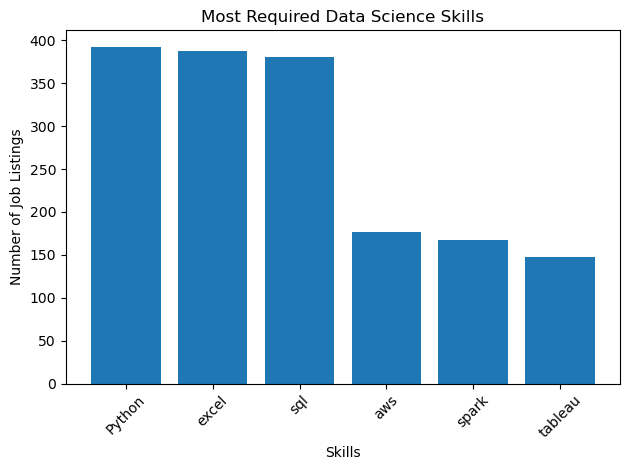

In [10]:
skills = ["Python","sql","excel","aws","spark","tableau"]

skill_counts = df[skills].sum().sort_values(ascending=False)

fig, ax = plt.subplots()

ax.bar(skill_counts.index, skill_counts.values)

ax.set_title("Most Required Data Science Skills")
ax.set_xlabel("Skills")
ax.set_ylabel("Number of Job Listings")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. Average Salary by Sector

In [ ]:
df.loc[:, "Sector"] = df["Sector"].replace("-1", "Unknown") # Replacing -1 with unknown in the sector

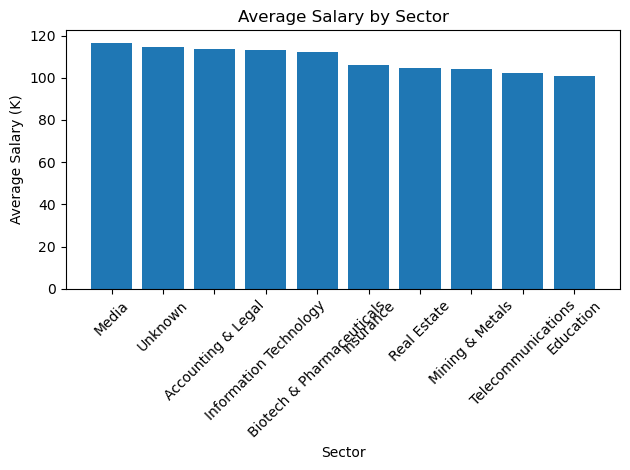

In [19]:
sector_salary = df.groupby("Sector")["Avg Salary(K)"].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()

ax.bar(sector_salary.index, sector_salary.values)

ax.set_title("Average Salary by Sector")
ax.set_xlabel("Sector")
ax.set_ylabel("Average Salary (K)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()